In [2]:
import sys
import os
sys.path.append(os.path.abspath("../.."))
from quantile_forest import RandomForestQuantileRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from tinyconformal.regressor import ConformalizedQuantileRegressor
from tinyconformal.plot import plot_prediction_intervals
import numpy as np

In [3]:
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_calib, y_train, y_calib = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [5]:
coverage = 0.80
alpha = 1 - coverage
quantiles = [alpha/2, 1 - alpha/2]

In [6]:
rf = RandomForestQuantileRegressor(random_state=42, default_quantiles=quantiles, n_jobs=-1, oob_score=True, max_depth=int(np.ceil(np.log2(len(X_train)) - 1)))
rf.fit(X_train, y_train)

,n_estimators,100
,default_quantiles,"[0.09999999999999998, 0.9]"
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [7]:
reg = ConformalizedQuantileRegressor(
    rf,
    alpha=alpha,
)
reg.fit(X_train, y_train, oob=True)

,learner,RandomForestQ...ndom_state=42)
,alpha,0.19999999999999996
,n_estimators,100
,default_quantiles,"[0.09999999999999998, 0.9]"
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0


In [8]:
y_pred_intervals = reg.predict_interval(X_test, alpha=0.2)
y_pred = reg.predict(X_test)

In [9]:
reg.evaluate(X_test, y_test, alpha=0.2)

{'total': 4128,
 'alpha': 0.2,
 'coverage_rate': np.float64(0.849),
 'interval_width_mean': np.float64(1.166),
 'mwis': np.float64(1.598),
 'mae': np.float64(0.364),
 'mbe': np.float64(0.042),
 'mse': np.float64(0.29)}

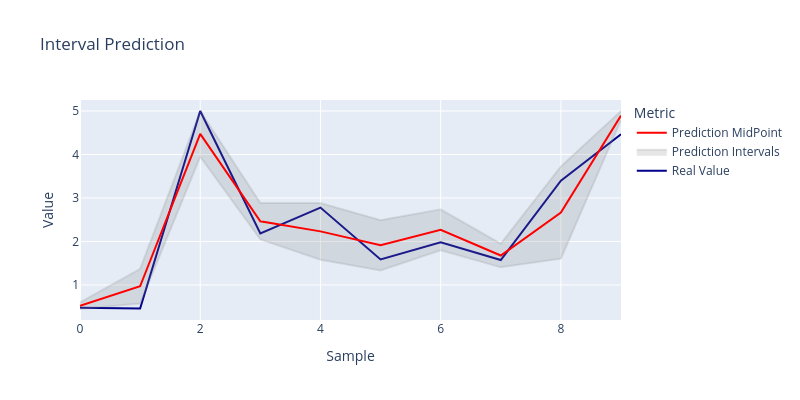

In [10]:
plot_prediction_intervals(y_pred_intervals[:10], y_pred[:10], y_test[:10], fig_type="png")